##1.IMPORTS

In [ ]:
import os
import requests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from google.colab import drive, userdata
import numpy as np
from PIL import Image
from io import BytesIO
from numba import njit, prange
import pickle
import math
from sklearn.decomposition import PCA

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!curl -O  'https://files.grouplens.org/datasets/movielens/ml-32m.zip'
#!curl -O  'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

In [ ]:
#!unzip 'ml-32m.zip'
#!unzip 'ml-latest-small.zip'

##2.READING DATA

In [ ]:
def get_file_data(name):
    '''
    This function opens a file for reading data.
    Parameters:
         name(str): file name
    Ouputs:
          file object: opened file.
    '''
    path = 'drive/MyDrive/ml_scale/ml-32m'

    file = open(os.path.join(path, name), 'r')
    return file

In [ ]:
def read_ratings(file_name):
    '''
    This function reads user ratings from csv file.
    Parameters:
         name(str): file name
    Yields:
        tuple: (user_id (int), movie_id (int), rating (float))
    '''
    print('started reading data!')
    with get_file_data(file_name) as f:
        next(f)  # skip header
        for line in f:
            user_id, movie_id, rating, timestamp = line.strip().split(',')
            yield int(user_id), int(movie_id), float(rating)
    print('reading data completed!')


def read_genres(file_name):
    """
    This function reads movie genres and titles from a csv file.

    Parameters:
        file_name (str): Name of the movies/genres file.

    Yields:
        tuple: (movie_id (int), title (str), genres (str))
    """
    print('started reading data!')
    with get_file_data(file_name) as f:
        next(f)  # skip header
        for line in f:

            data= line.strip().split(',')

            movie_id = int(data[0])
            genres = str(data[-1])

            # to include titles with commas
            title = ','.join(data[1:-1])
            yield int(movie_id), str(title), str(genres)
    print('reading data completed!')


def read_links(file_name):
    """
    This function reads movie link information (IMDb and TMDB IDs)
    from a csv file.

    Parameters:
        file_name (str): Name of the links file.

    Yields:
        tuple: (movie_id (int), imdb_id (str), tmdb_id (str))
    """
    print('started reading data!')
    with get_file_data(file_name) as f:
        next(f)  # skip header
        for line in f:
            movie_id, imdbId, tmbdId = line.strip().split(',')
            yield int(movie_id), imdbId, tmbdId
    print('reading data completed!')

## 3.DATA STRUCTURE CLASS

In [ ]:
class MyDataStruct():
     """
     This class stores and manages movie ratings data, including training and test splits,
     mapping between user/movie IDs and internal indices, and optimized flattened structures.
     """
     def __init__(self,train_split=0.2):
         # train test split  ratio of data to use for testing
        self.train_split_ratio = train_split

        # lists to map indices back to IDs
        self.idx_to_movie_id =[]
        self.idx_to_user_id = []

        # dictionaries to map IDs to indices
        self.movie_id_to_idx = {}
        self.user_id_to_idx = {}

        # dictionaries to store start indices of flattened test/train data
        self.movie_id_to_data_idx_test = {}
        self.user_id_to_data_idx_test = {}
        self.movie_id_to_data_idx_train = {}
        self.user_id_to_data_idx_train = {}

        # lists of lists to store test data as its read from file
        self.data_by_movie_test = []
        self.data_by_user_test = []

        # flattened list to store test data for quick access
        self.rating_data_by_user_test = [] # ratings data by user
        self.rating_data_by_movie_test = [] #rating data by movie
        self.id_data_by_user_test = [] # idx data by user
        self.id_data_by_movie_test = [] # idx data by movie


        # lists of lists to store train data as its read from file
        self.data_by_movie_train = []
        self.data_by_user_train = []

        # flattened list to store train data for quick access
        self.rating_data_by_user_train = [] # ratings data by user
        self.rating_data_by_movie_train = [] # ratings data by movie
        self.id_data_by_user_train = [] # idx data by user
        self.id_data_by_movie_train = [] # idx data by movie

        #variables to store statistics about the dataset
        self.counts = 0  # total entries in the rating dataset
        self.train_count = 0 # total entries in train rating data
        self.test_count = 0  # total entries in test rating data

        #rating bins for plotting rating statistics
        self.rating_bins = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
        self.rating_counts = {r: 0 for r in self.rating_bins}
        #dictionary to store movie meta data (genre, title and IMDB IDs)
        self.movie_data={}
        #list of all genres in the data
        self.genere_labels = []

     def get_or_create_user_idx(self,user_id):
          """
           This function returns the internal index for an existing  user_id or  creates a new user entry if necessary.
           Also initializes data structures for training and test data.
           Input:
                user_id(int): ID for user
           Output:
                 int: internal index for accessing the rating data by user
           """
          idx = -1
          if user_id in self.user_id_to_idx:
              # get user idx if user exists
              idx = self.user_id_to_idx[user_id]
          else:
            # creating new index for user data
            idx=len(self.idx_to_user_id)
            self.idx_to_user_id.append(user_id)
            self.user_id_to_idx[user_id] = idx


            #data structures for train test split
            self.data_by_user_train.append([])
            self.data_by_user_test.append([])
          return idx
     def get_or_create_movie_idx(self,movie_id):
          """
           This function returns the internal index for an existing  movie_id or  creates a new movie entry if necessary.
           Also initializes data structures for training and test data.
           Input:
                movie_id(int): ID for movie
           Output:
                 int: internal index for accessing rating data by movie
           """
          idx = -1
          if movie_id in self.movie_id_to_idx:
              #get movie  idx if movie exists
              idx=self.movie_id_to_idx[movie_id]
          else:
            # creating new index for movie data
            idx = len(self.idx_to_movie_id)
            self.idx_to_movie_id.append(movie_id)
            self.movie_id_to_idx[movie_id] = idx


            # data structures for train test split
            self.data_by_movie_test.append([])
            self.data_by_movie_train.append([])
          return idx

     def load_data(self,file_name):
         """
         This functions loads ratings data from a file, and  splits it into training and test sets,
         and call the optimization function to create optimized data structures.
         Input:
             file_name(str): file name
         Output:
              None
         """
         print('started loading data')
         opts={
                          0:False, #for train
                          1:True #for test
                      }

         total = self.counts
         ratio = self.train_split_ratio
         train_ratio = 1 - ratio
         for user_id, movie_id, rating in read_ratings(file_name):

              total = self.counts
              test_count = self.test_count
              train_count = self.train_count
               # Get internal indices for user and movie
              user_idx=self.get_or_create_user_idx(user_id)
              movie_idx=self.get_or_create_movie_idx(movie_id)

              # Randomly decide if this rating goes to test set
              choice=choice = np.random.rand() < ratio

              desired_test_count = ratio * total
              desired_train_count = train_ratio * total

              if (test_count >= desired_test_count) and (choice == False):
                    # if too many test values
                    choice = False

              if (train_count >= desired_train_count) and (choice == True):
                      # if too many train values
                      choice = True
              # Add rating to appropriate split
              self.add_train_split_data(user_idx,movie_idx,rating,choice)
              # Update the statistics  counters
              self.rating_counts[rating] += 1
              self.counts += 1
         print('data loading completed!')
         #self.trains_split()
         #optimization
         self.optimize_data_struct()
     def optimize_data_struct(self):
         """
          This function creates a flatten training and test data structure for efficient access.
          Converts lists of lists into continuous arrays and records start indices for each user/movie.
          At the start index in the optimized data structure, size of the entries for the user/movie is entered.
         """
         print('###data structure optimization started')

         print('optimizing training data')

         #Flatten  training data by movie
         data_list = self.data_by_movie_train
         rating_list = self.rating_data_by_movie_train
         id_list = self.id_data_by_movie_train
         for n in range(len(data_list)):
                  movie_idx = n
                  movie_id = self.idx_to_movie_id[movie_idx]
                  data = data_list[n]
                  num = len(data)
                  data_idx = len(rating_list)

                  # First element stores number of ratings
                  rating_list.append(num)
                  id_list.append(num)
                  # Append all user indices and ratings
                  for (user_idx,rating) in data:
                       rating_list.append(rating)
                       id_list.append(user_idx)
                  # Store start index for this movie
                  self.movie_id_to_data_idx_train[movie_id] = data_idx

         # Flatten training data by user
         data_list = self.data_by_user_train
         rating_list = self.rating_data_by_user_train
         id_list=self.id_data_by_user_train
         for m in range(len(data_list)):
                  user_idx = m
                  user_id = self.idx_to_user_id[user_idx]
                  data = data_list[m]
                  num = len(data)
                  data_idx = len(rating_list)
                  # First element stores number of ratings
                  rating_list.append(num)
                  id_list.append(num)
                  # Append all user indices and ratings
                  for (movie_idx,rating) in data:
                       rating_list.append(rating)
                       id_list.append(movie_idx)
                  # Store start index for this movie
                  self.user_id_to_data_idx_train[user_id] = data_idx
         print('optimizing test data')
        # Flatten test data by movie
         data_list = self.data_by_movie_test
         rating_list = self.rating_data_by_movie_test
         id_list = self.id_data_by_movie_test
         for n in range(len(data_list)):
                  movie_idx = n
                  movie_id = self.idx_to_movie_id[movie_idx]
                  data = data_list[n]
                  num = len(data)
                  data_idx = len(rating_list)
                  # First element stores number of ratings
                  rating_list.append(num)
                  id_list.append(num)
                  # Append all user indices and ratings
                  for (user_idx,rating) in data:
                       rating_list.append(rating)
                       id_list.append(user_idx)
                  # Store start index for this movie
                  self.movie_id_to_data_idx_test[movie_id ]= data_idx

         # Flatten test data by user
         data_list = self.data_by_user_test
         rating_list = self.rating_data_by_user_test
         id_list=self.id_data_by_user_test
         for m in range(len(data_list)):
                  user_idx = m
                  user_id = self.idx_to_user_id[user_idx]
                  data = data_list[m]
                  num = len(data)
                  data_idx = len(rating_list)
                  # First element stores number of ratings
                  rating_list.append(num)
                  id_list.append(num)
                  # Append all user indices and ratings
                  for (movie_idx,rating) in data:
                       rating_list.append(rating)
                       id_list.append(movie_idx)
                  # Store start index for this movie
                  self.user_id_to_data_idx_test[user_id] = data_idx
         print('###data structure optimization started!')
         print('###train split completed!')
     def load_item_data(self,genre_file,link_file,get_links=True,get_genre=True):
         """
          This function loads movie metadata (genres, titles, IMDB/TMDB links) and store it in self.movie_data.

          Inputs:
          genre_file(str): Path to the genres file.
          link_file (str): Path to the links file with IMDB IDs.
          get_links (bool): Boolean to check whether to load link data.
          get_genre (bool): Boolean to check whether to load genre/title data.

          Output:
             None
          """

         print('started loading genre data')
         if(get_genre == True):
            # Load genres and titles from file
            for movie_id, title, genres in read_genres(genre_file):
                          # Store title + genre for this movie
                          self.movie_data[movie_id]={
                              'title':title,
                              'genre':genres
                          }
                          # Extract unique genre labels
                          genre_labels=genres.split('|')
                          for genre in genre_labels:
                               if genre not in self.genere_labels:
                                   self.genere_labels.append(genre)


         print('data loading completed!')

         print('started loading link data')
         if(get_links==True):
             # Load IMDB/TMDB IDs for creating poster urls/links
            for movie_id, imdbId,tmbdId in read_links(link_file):
                      if movie_id in self.movie_data:
                          self.movie_data[movie_id]['imdbId']=imdbId
                          self.movie_data[movie_id]['tmbdId']=tmbdId
                      else:
                          self.movie_data[movie_id]={
                              'imdbId':imdbId,
                              'tmbdId':tmbdId
                          }
         print('data loading completed!')


     def add_user_data(self,user_idx,data):
           """
            This function appends a (movie_idx, rating) entry to the user's list of rating data.

            Inputs:
                user_idx (int): Internal user index.
                data (tuple): A tuple containing (movie_idx, rating).
            """
           self.data_by_user[user_idx].append(data)

     def add_movie_data(self,movie_idx,data):
            """
              This function appends a (user_idx, rating) entry to the movie's list of rating data.

              Inputs:
                  movie_idx (int): Internal movie index.
                  data (tuple): A tuple containing (user_idx, rating).
            """
            self.data_by_movie[movie_idx].append(data)

     def add_train_split_data(self,user_idx,movie_idx,rating,to_test=False):
         """
          This function stores a user and movie rating either in the training set
          or the test set depending on the 'to_test' boolean check.

          Inputs:
              user_idx (int): Internal user index.
              movie_idx (int): Internal movie index.
              rating (float or int): Rating value.
              to_test (bool): Boolean to check whether the data should be added to the test split.
        """

         if(to_test== True):
            # Test data
            self.data_by_movie_test[movie_idx].append((user_idx,rating))
            self.data_by_user_test[user_idx].append((movie_idx,rating))

            self.test_count+=1

         else:
            # Training data
            self.data_by_movie_train[movie_idx].append((user_idx,rating))
            self.data_by_user_train[user_idx].append((movie_idx,rating))

            self.train_count+=1

     def get_data_by_movies(self):
            """
            This function returns a list of combined train+test rating data for each movie.

            Outputs:
                list: A list where each element contains all (user_idx, rating)
                      pairs for the corresponding movie.
            """
            data=[]
            for idx in range(len(self.idx_to_movie_id)):
                  data_train=self.data_by_movie_train[idx]
                  data_test=self.data_by_movie_test[idx]
                  data.append(data_train+data_test)
            return data
     def get_data_by_users(self):
            """
              This function returns a list of combined train+test rating data for each user.

              Outputs:
                  list: A list where each element contains all (movie_idx, rating)
                        pairs for the corresponding user.
            """
            data=[]
            for idx in range(len(self.idx_to_user_id)):
                  data_train=self.data_by_user_train[idx]
                  data_test=self.data_by_user_test[idx]
                  data.append(data_train+data_test)
            return data

     def get_data_by_movie_id(self,movie_id,use_idx=False):
             """
              This function returns all rating data (train + test) for a given movie id.

              Inputs:
                  movie_id (int): External movie ID unless use_idx=True.
                  use_idx (bool): If True, 'movie_id' is treated as an internal movie index.

              Outputs:
                  list: A combined list of (user_idx, rating) pairs for the movie.
             """

             if movie_id not in self.movie_id_to_idx and use_idx!=True:
                  print('Movie ID not found!')
                  return None
             if(use_idx==False):
                   movie_idx=self.movie_id_to_idx[movie_id]
             else:
                   movie_idx=movie_id
             data_train=self.data_by_movie_train[movie_idx]
             data_test=self.data_by_movie_test[movie_idx]
             return (data_train+data_test)

     def get_data_by_user_id(self,user_id,use_idx=False):
             """
              This function returns all rating data (train + test) for a given user id.

              Inputs:
                  user_id (int): External user ID unless use_idx=True.
                  use_idx (bool): If True, 'user_id' is treated as an internal user index.

              Outputs:
                  list: A combined list of (movie_idx, rating) pairs for the user.
             """
             if user_id not in self.user_id_to_idx and use_idx!=True:
                  print('User ID not found!')
                  return None
             if(use_idx==False):
                 user_idx=self.user_id_to_idx[user_id]
                 id=user_id
             else:
                  user_idx=user_id


             data_train=self.data_by_user_train[user_idx]
             data_test=self.data_by_user_test[user_idx]
             return (data_train+data_test)
     def get_data_by_movie_train(self,movie_id,use_idx=False):
             """
              This function returns all training ratings for a given movie.

              Inputs:
                  movie_id (int): External movie ID unless use_idx=True.
                  use_idx (bool): If True, 'movie_id' is treated as an internal movie index.

              Outputs:
                  list: A list of (user_idx, rating) pairs from the training set.
             """
             if movie_id not in self.movie_id_to_idx and use_idx!=True:
                  print('Movie ID not found!')
                  return None
             if(use_idx==False):
                 movie_idx=self.movie_id_to_idx[movie_id]
             else:
                  movie_idx=movie_id
             return self.data_by_movie_train[movie_idx]
     def get_data_by_movie_test(self,movie_id,use_idx=False):
             """
              This function returns all test ratings for a given movie.

              Inputs:
                  movie_id (int): External movie ID unless use_idx=True.
                  use_idx (bool): If True, 'movie_id' is treated as an internal movie index.

              Outputs:
                  list: A list of (user_idx, rating) pairs from the test set.
              """

             if movie_id not in self.movie_id_to_idx and use_idx!=True:
                  print('Movie ID not found!')
                  return None
             if(use_idx==False):
                 movie_idx=self.movie_id_to_idx[movie_id]
             else:
                  movie_idx=movie_id
             return self.data_by_movie_test[movie_idx]
     def get_data_by_user_train(self,user_id,use_idx=False):
             """
              This function returns all training rating data for a given user.

              Inputs:
                  user_id (int): External user ID unless use_idx=True.
                  use_idx (bool): If True, 'user_id' is treated as an internal user index.

              Outputs:
                  list: A list of (movie_idx, rating) pairs from the training set.
              """

             if user_id not in self.user_id_to_idx and use_idx!=True:
                  print('User ID not found!')
                  return None
             if(use_idx==False):
                  user_idx=self.user_id_to_idx[user_id]
             else:
                  user_idx=user_id
             return self.data_by_user_train[user_idx]
     def get_data_by_user_test(self,user_id,use_idx=False):
             """
            This function returns all test rating data for a given user.

            Inputs:
                user_id (int): External user ID unless use_idx=True.
                use_idx (bool): If True, 'user_id' is treated as an internal user index.

            Outputs:
                list: A list of (movie_idx, rating) pairs from the test set.
            """

             if user_id not in self.user_id_to_idx and use_idx!=True:
                  print('Movie ID not found!')
                  return None
             if(use_idx==False):
                 user_idx=self.user_id_to_idx[user_id]
             else:
                  user_idx=user_id
             return self.data_by_user_test[user_idx]

     def get_ratings_vector_by_movie(self,movie_id,use_idx=False,is_train=True):
                 """
                This function returns a vector of rating values for a given movie.

                Inputs:
                    movie_id (int): External movie ID unless use_idx=True.

                    use_idx (bool): If True, 'movie_id' is treated as
                    an internal movie index.

                    is_train (bool): If True, return training ratings;
                    otherwise return test ratings.

                Outputs:
                    numpy array: Array of rating values for the movie.
                 """
                 if(use_idx==True):
                      movie_id=self.idx_to_movie_id[movie_id]

                 data_idx=self.movie_id_to_data_idx_train[movie_id]
                 data_list=self.rating_data_by_movie_train

                 if(is_train==False):
                     data_idx=self.movie_id_to_data_idx_test[movie_id]
                     data_list=self.rating_data_by_movie_test

                 num=data_list[data_idx]
                 start=int(data_idx+1)
                 end=int(data_idx+num+1)
                 return np.array(data_list[start:end])
     def get_ratings_vector_by_user(self,user_id,use_idx=False,is_train=True):
                 """
              This function returns a vector/array of rating values for a given
              user.

              Inputs:
                  user_id (int): External user ID unless use_idx=True.

                  use_idx (bool): If True, user_id is treated as an internal
                   user index.

                  is_train (bool): If True, return training ratings; otherwise
                  return test ratings.

              Outputs:
                  numpy array: Array of rating values for the user.
              """
                 if(use_idx==True):
                      user_id=self.idx_to_user_id[user_id]

                 data_idx=self.user_id_to_data_idx_train[user_id]

                 data_list=self.rating_data_by_user_train


                 if(is_train==False):
                     data_idx=self.user_id_to_data_idx_test[user_id]
                     data_list=self.rating_data_by_user_test

                 num=data_list[data_idx]
                 start=int(data_idx+1)
                 end=int(data_idx+num+1)

                 return np.array(data_list[start:end])
     def get_ids_vector_by_movie(self,movie_id,use_idx=False,is_train=True):
                 """
                This function returns a vector/array of user indices for a given
                movie.

                Inputs:
                    movie_id (int): External movie ID unless use_idx=True.

                    use_idx (bool): If True, movie_id is treated as an
                    internal movie index.

                    is_train (bool): If True, return training user IDs;
                    otherwise test user IDs.

                Outputs:
                    numpy array: Array of user indices who rated the movie.
                """
                 if(use_idx==True):
                      movie_id=self.idx_to_movie_id[movie_id]

                 data_idx=self.movie_id_to_data_idx_train[movie_id]
                 data_list=self.id_data_by_movie_train

                 if(is_train==False):
                     data_idx=self.movie_id_to_data_idx_test[movie_id]
                     data_list=self.id_data_by_movie_test

                 num=data_list[data_idx]
                 start=int(data_idx+1)
                 end=int(data_idx+num+1)
                 return np.array(data_list[start:end])
     def get_ids_vector_by_user(self,user_id,use_idx=False,is_train=True):
                 """
            This function returns a vector of movie indices rated by a given
            user.

            Inputs:
                user_id (int): External user ID unless use_idx=True.

                 use_idx (bool): If True, 'user_id' is treated as an internal
                user index.

                is_train (bool): If True, return training movie IDs; otherwise
                test movie IDs.

            Outputs:
                numpy array: Array of movie indices rated by the user.
            """
                 if(use_idx==True):
                      user_id=self.idx_to_user_id[user_id]

                 data_idx=self.user_id_to_data_idx_train[user_id]
                 data_list=self.id_data_by_user_train

                 if(is_train==False):
                     data_idx=self.user_id_to_data_idx_test[user_id]
                     data_list=self.id_data_by_user_test

                 num=data_list[data_idx]
                 start=int(data_idx+1)
                 end=int(data_idx+num+1)
                 return np.array(data_list[start:end])

     def get_movie_url(self,movie_id,use_idx=False,database=2):
             """
              This function returns the URL of a movie from MovieLens, IMDB, or
              TMDB.

              Inputs:
                  movie_id (int): External movie ID unless use_idx=True.

                  use_idx (bool): If True, treat 'movie_id' as an internal
                  index.

                  database (int): Select which URL source to generate:
                                  1 =>  MovieLens
                                  2 => IMDB
                                  3 => TMDB

              Outputs:
                  str: A fully generated URL pointing to the chosen movie page.
              """
             if(use_idx==True):
                 movie_id=self.idx_to_movie_id[movie_id]
             source={
                 1:'https://movielens.org/movies',
                 2: 'http://www.imdb.com/title',
                 3: 'https://www.themoviedb.org/movie'
             }
             id={
                 1:movie_id,
                 2:'tt'+str(self.movie_data[movie_id]['imdbId']),
                 3:self.movie_data[movie_id]['tmbdId']
             }
             url_id=id[database]
             src=source[database]
             return src+f'/{str(url_id)}/'
     def get_movie_poster(self, movie_id, use_idx=False):
            """
            This function accesses the OMDB API to retrieve the poster URL for a
            movie.

            Inputs:
                movie_id (int): External movie ID unless use_idx=True.

                use_idx (bool): If True, treat 'movie_id' as an internal index.

            Outputs:
                str or None: The poster image URL if available; otherwise None.
            """
            if use_idx:
                movie_id = self.idx_to_movie_id[movie_id]
            imdb_id = 'tt'+self.movie_data[movie_id].get('imdbId')
            key= userdata.get('omdb')
            if not imdb_id:
                return None

            url = f'http://www.omdbapi.com/?i={imdb_id}&apikey={key}'
            try:
                 response = requests.get(url, timeout=10)
                 data = response.json()
            except ValueError:

                  print(f"Error fetching poster:ID={movie_id}")
                  return None
            poster_url = data.get('Poster')
            return poster_url
     def generate_image(self,movie_id,use_idx=False,display=True):
        """
        This function downloads and returns a movie poster as a PIL Image object.

        Inputs:
            movie_id (int): External movie ID unless use_idx=True.
            use_idx (bool): If True, treat 'movie_id' as an internal index.
            display (bool): If True, automatically display the image.

        Outputs:
            Pillow Image Object or None: The poster image object, or None
            if unavailable.
        """
        poster_url=self.get_movie_poster(movie_id,use_idx)
        if poster_url and poster_url != 'N/A':
            response = requests.get(poster_url)
            img = Image.open(BytesIO(response.content))
            if(display==True):
                img.show()
            return img
        else:
            print("No poster available")
            return None
     def get_movie_data(self,movie_id,use_idx=False):
             """
          This function retrieves all metadata associated with a specific movie.

          Inputs:
              movie_id (int): External movie ID unless use_idx=True.

              use_idx (bool): If True, treat 'movie_id' as an internal index.

          Outputs:
              dict: Dictionary containing stored metadata for the movie.
           """
             if(use_idx==True):
                 movie_id=self.idx_to_movie_id[movie_id]
             return self.movie_data[movie_id]
     def get_ratings(self):
        """
        This function collects all rating values across the entire dataset.

        Inputs:
            None

        Outputs:
            list: A flat list of all rating values.
        """
        rating=[]
        for data in self.data_by_movie:
            for entry in data:
                 rating.append(entry[1])
        return rating

##4.DATA STRUCTURE INSTANCE & TRAIN SPLIT DATA ONLOAD

In [ ]:
#creating new data structure instance
data_structure=MyDataStruct(train_split = 0.1)
#loading the rating data from csv file
data_structure.load_data('ratings.csv')
#loadign the movie meta data from csv file
data_structure.load_item_data('movies.csv','links.csv')

started loading data
started reading data!
reading data completed!
data loading completed!
###data structure optimization started
optimizing training data
optimizing test data
###data structure optimization started!
###train split completed!
started loading genre data
started reading data!
reading data completed!
data loading completed!
started loading link data
started reading data!
reading data completed!
data loading completed!


# 5.DATA EXPLORATION AND RATING DISTRIBUTIONS


### 5.1.Movie Rating Frequency

In [ ]:
# getting the data by all movies
movie_data=data_structure.get_data_by_movies()
# getting the number of ratigns for the movies
movie_degrees = [len(movie_rating) for  movie_rating in movie_data]

movie_frequency={}
# counting the frequency of the ratings
for degree in movie_degrees:
    if degree in movie_frequency:
        movie_frequency[degree]+=1
    else:
        movie_frequency[degree]=1
#converting the data to numpy
movie_degree_axis=np.array(list(movie_frequency.keys()))
movie_frequency_axis=np.array(list(movie_frequency.values()))


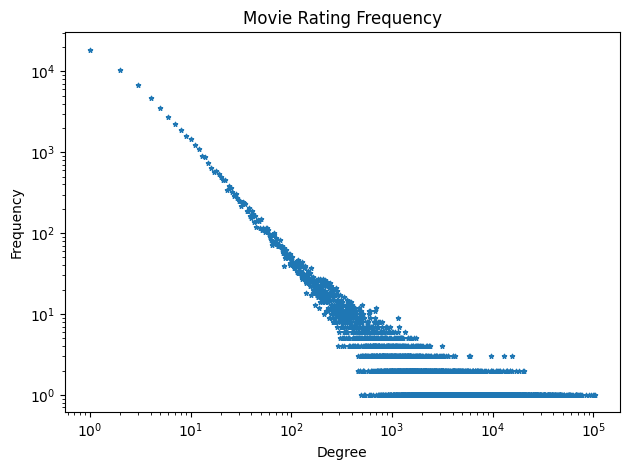

In [ ]:
# plotting the movie rating frequency
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='*', s=10)
plt.title("Movie Rating Frequency")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
# saving the plot to file
plt.savefig('drive/MyDrive/ml_scale/movie_rating_frequency.pdf',format='pdf',dpi=300)
plt.show()

### 5.2.Power Law Plot(Movie Rating)

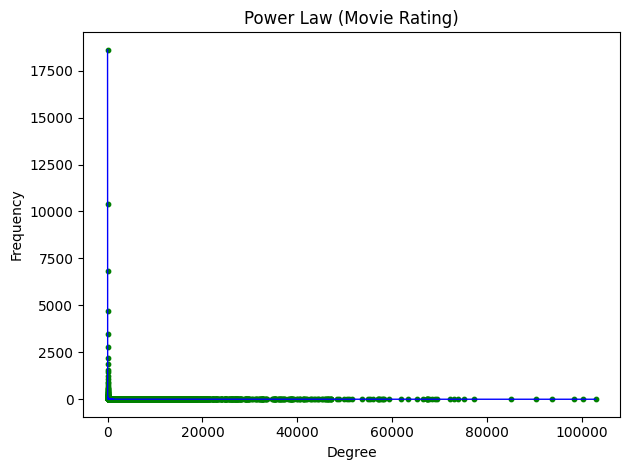

In [ ]:
# plotting the power law based on the movie plots
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='o',color='green', s=10)
idx = np.argsort(movie_degree_axis)
plt.plot(movie_degree_axis[idx],movie_frequency_axis[idx],'b-',lw=1)
plt.title("Power Law (Movie Rating)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.tight_layout()
# saving the plot to file
plt.savefig('drive/MyDrive/ml_scale/power_law_movie_rating.pdf',format='pdf',dpi=300)
plt.show()

### 5.3.User Rating Frequency

In [ ]:
# getting the number of ratings by user data
user_degrees = [len(user_rating) for  user_rating in data_structure.get_data_by_users()]
user_frequency={}

# counting the frequency of the ratings
for degree in user_degrees:
    if degree in user_frequency:
        user_frequency[degree]+=1
    else:
        user_frequency[degree]=1
#converting the data to numpy
user_degree_axis=np.array(list(user_frequency.keys()))
user_frequency_axis=np.array(list(user_frequency.values()))

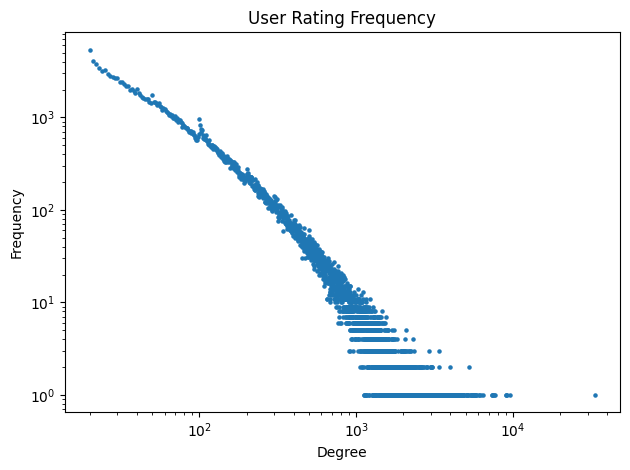

In [ ]:
# plotting the user rating frequeny
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=5)
plt.title("User Rating Frequency")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
#saving the plot to file
plt.savefig('drive/MyDrive/ml_scale/user_rating_frequency.pdf',format='pdf',dpi=300)
plt.show()

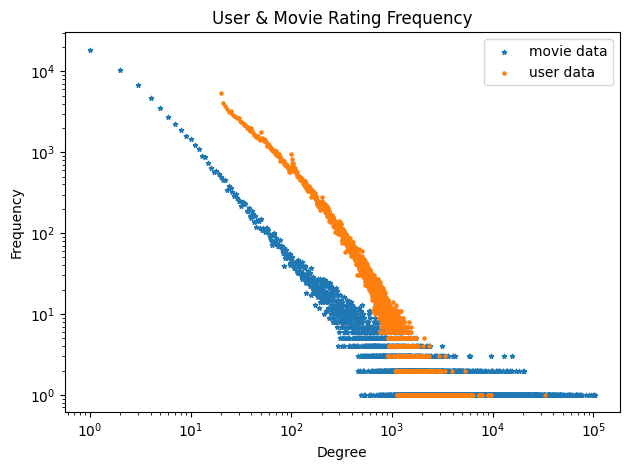

In [ ]:
# plotting the user and movie rating frequency on same graph
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='*', s=10,label='movie data')
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=5,label='user data')
plt.title("User & Movie Rating Frequency")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='upper right')
plt.tight_layout()
# saving plot to file
plt.savefig('drive/MyDrive/ml_scale/user_movie_rating_frequency.pdf',format='pdf',dpi=300)
plt.show()

### 5.4.Power Law Plot (User Rating)

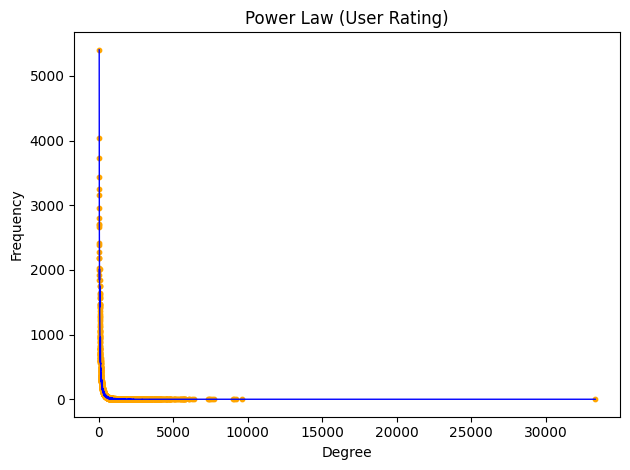

In [ ]:
# plotting power law based user data
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=10,color='orange')
idx2 = np.argsort(user_degree_axis)
plt.plot(user_degree_axis[idx2],user_frequency_axis[idx2],'b-',lw=1)
plt.title("Power Law (User Rating)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.tight_layout()
# saving plot to file
plt.savefig('drive/MyDrive/ml_scale/power_law_user_rating.pdf',format='pdf',dpi=300)
plt.show()

### 5.5.Histogram of Rating Counting

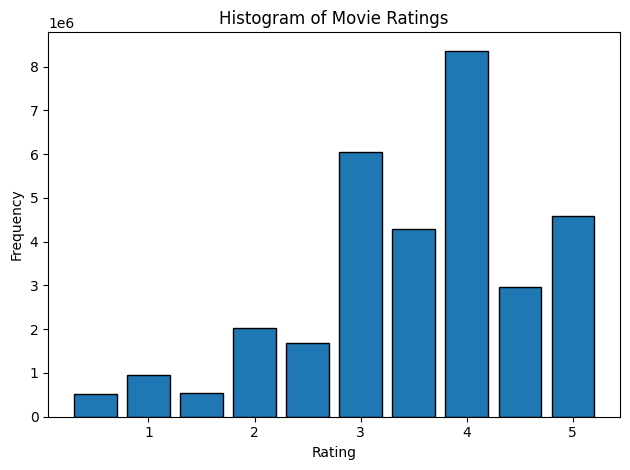

In [ ]:
#accessing the ratings for the dataset
ratings = list(data_structure.rating_counts.keys())
counts = list(data_structure.rating_counts.values())
# plotting histogram of movies ratings and their frequency
plt.bar(ratings, counts, width=0.4, edgecolor='black')
plt.title("Histogram of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
#saving plot to file
plt.savefig('drive/MyDrive/ml_scale/movie_rating_historgram.pdf',format='pdf',dpi=300)
plt.show()

## 6.5 Genre Histogram

In [ ]:
# get list of all genre labels
genre_labels = data_structure.genere_labels
# initialize counters: total ratings per genre
genre_counts={genre:0 for genre in genre_labels}
# initialize counters: number of movies per genre
genre_movie_counts={genre:0 for genre in genre_labels}
# initialize dictionary to hold running average ratings per genre
genre_avg_ratings={genre:0 for genre in genre_labels}
# get all movie IDs in the dataset
movies_ids = data_structure.idx_to_movie_id
# loop through each movie and compute genre statistics
for id in movies_ids:
    # get the genre list/string for this movie
    genre_info=data_structure.get_movie_data(id)['genre']
    rating_data=data_structure.get_data_by_movie_id(id)
    movie_user_count=len(rating_data)
    # match the movie against each genre label
    for genre in genre_labels:
         if genre.lower() in genre_info.lower():
             genre_movie_counts[genre]+=1
             current_count=genre_counts[genre]
             genre_avg_ratings[genre]*=current_count
             for (_,rating) in rating_data:
                     genre_avg_ratings[genre]+=rating
             genre_counts[genre]+=movie_user_count
             genre_avg_ratings[genre]/=genre_counts[genre]

# convert data to numpy array
genre_axis=np.array(list(genre_labels))
genre_rating_frequency_axis=np.array(list(genre_counts.values()))
genre_movie_frequency_axis=np.array(list(genre_movie_counts.values()))
genre_rating_axis=np.array(list(genre_avg_ratings.values()))


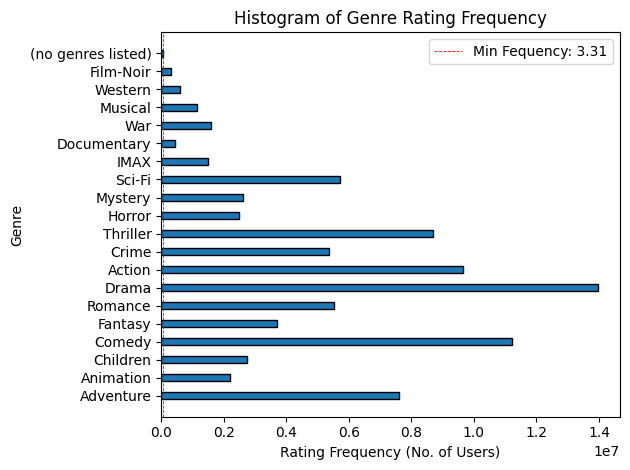

In [ ]:
# plotting histogram of genre frequency
plt.barh(genre_axis, genre_rating_frequency_axis, height=0.4, edgecolor='black')
plt.title("Histogram of Genre Rating Frequency")
plt.ylabel("Genre")
plt.xlabel("Rating Frequency (No. of Users)")
plt.axvline(x=min(genre_rating_frequency_axis), color='red', lw=0.6,linestyle='--', label=f'Min Fequency: {min(genre_rating_axis):.2f}')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/genre_frequency.pdf',format='pdf',dpi=300)
plt.show()

## 5.6 Genre Average Rating Histogram

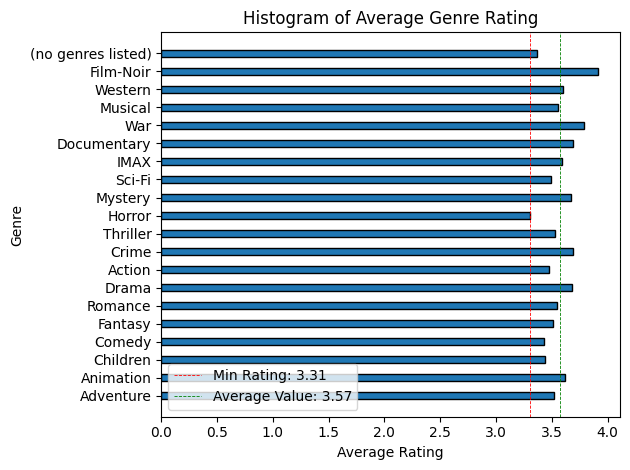

In [ ]:
#plotting histogram of genre average rating
plt.barh(genre_axis, genre_rating_axis, height=0.4, edgecolor='black')
plt.title("Histogram of Average Genre Rating")
plt.ylabel("Genre")
plt.xlabel("Average Rating")
plt.xticks(rotation=0)
plt.axvline(x=min(genre_rating_axis), color='red',lw=0.6, linestyle='--', label=f'Min Rating: {min(genre_rating_axis):.2f}')
plt.axvline(x=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/genre_average_rating.pdf',format='pdf',dpi=300)
plt.show()

## 5.7 Genre Average Rating Vs Popularity/Degree

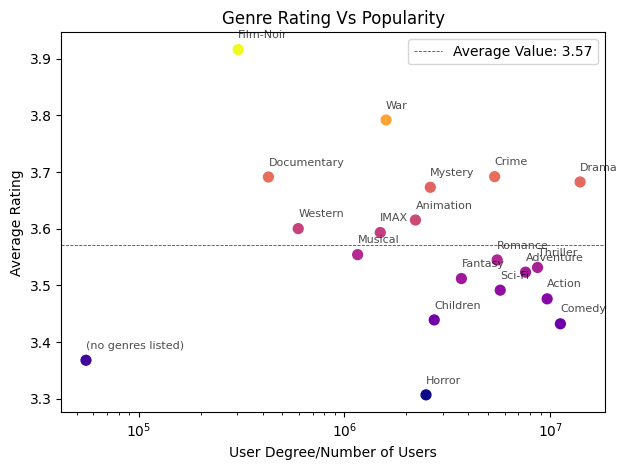

In [ ]:
plt.scatter(genre_rating_frequency_axis,genre_rating_axis ,c=genre_rating_axis ,marker='o',cmap='plasma', s=50)
plt.title("Genre Rating Vs Popularity")
plt.xlabel("User Degree/Number of Users")
plt.ylabel("Average Rating")
plt.axhline(y=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.xscale('log')
for x, y, label in zip(genre_rating_frequency_axis, genre_rating_axis, genre_labels):
    plt.text(x+0.02, y+0.02, label, fontsize=8, alpha=0.7)
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig('drive/MyDrive/ml_scale/genere_av_rating_degree.pdf',format='pdf',dpi=300)
plt.show()

## 5.8 Genre Average Rating Vs Movie Degree

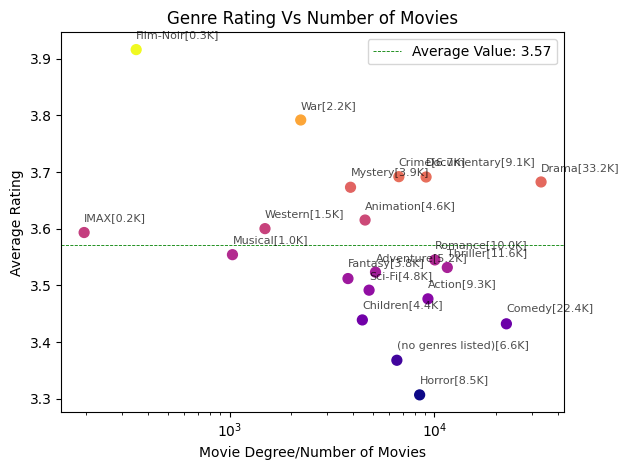

In [ ]:
plt.scatter(genre_movie_frequency_axis,genre_rating_axis ,c=genre_rating_axis ,marker='o',cmap='plasma', s=50)
plt.title("Genre Rating Vs Number of Movies")
plt.xlabel("Movie Degree/Number of Movies")
plt.ylabel("Average Rating")
plt.axhline(y=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.xscale('log')
for x, y, label in zip(genre_movie_frequency_axis, genre_rating_axis, genre_labels):
    count=genre_movie_counts[label]
    count_k = count / 1000
    count_str = f"{count_k:.1f}K"

    genre_label=label+f"[{count_str}]"
    plt.text(x+0.02, y+0.02, genre_label, fontsize=8, alpha=0.7)
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig('drive/MyDrive/ml_scale/genere_av_rating_mov_degree.pdf',format='pdf',dpi=300)
plt.show()

# 6.TRAINING WITH BIAS ONLY [TRAINING ON SMALL DATA]


In [ ]:
#function to print training process
def print_epochs(epoch,epochs,data,prints=10):
           every=epochs//prints
           if(every==0):
               every=1

           if((epoch+1)%every == 0 or epoch == epochs ):
                print(data)


In [ ]:
#Training loop: compatible with small data
data=data_structure
#number of users
M = len(data.idx_to_user_id)
#number of movie
N = len(data.idx_to_movie_id)

#initialization
user_biases=np.zeros((M))
item_biases=np.zeros((N))


#lambda
lambda_param=0.1
gamma=0.1

#iteractions
epochs=15
#variables to store loss after iteractions
train_nloglikelihood=[]
test_nloglikelihood=[]

train_rmse=[]
test_rmse=[]

for epoch in range(epochs):
    Likelihood_train=0
    Likelihood_test=0

    RMSE_train=0
    RMSE_test=0

    train_rmse_count=0
    test_rmse_count=0
    #computing user biases
    for m in range(M):
        bias=0
        item_counter=0

        for (n,r) in data.get_data_by_user_train(m,True):
            bias+=lambda_param*(r-(item_biases[n]))
            item_counter+=1
        bias=bias/(lambda_param*item_counter+gamma)
        user_biases[m]=bias

    #computing item biases and losses
    for n in range(N):
        bias=0
        item_counter=0

        for (m,r) in data.get_data_by_movie_train(n,True):
            bias+=lambda_param*(r-(user_biases[m]))
            item_counter+=1
        bias=bias/(lambda_param*item_counter+gamma)
        item_biases[n]=bias
    # computing loss using train data
    for n in range(N):
        for (m,r) in data.get_data_by_movie_train(n,True):
              pred=user_biases[m]+item_biases[n]
              err=(r-pred)**2
              RMSE_train+=err
              train_rmse_count+=1
    # computing loss using test data
    for n in range(N):
        for (m,r) in data.get_data_by_movie_test(n,True):
              pred=user_biases[m]+item_biases[n]
              err=(r-pred)**2
              RMSE_test+=err
              test_rmse_count+=1

    Likelihood_train=(0.5*lambda_param)*RMSE_train+0.5 * gamma* (user_biases**2).sum()+0.5 * gamma * (item_biases**2).sum()
    Likelihood_test=(0.5*lambda_param)*RMSE_test+0.5 * gamma * (user_biases**2).sum()+0.5 * gamma * (item_biases**2).sum()

    RMSE_train=np.sqrt(RMSE_train/max(train_rmse_count,1))
    RMSE_test=np.sqrt(RMSE_test/max(test_rmse_count,1))

    print_epochs(epoch,epochs,
                  f'#### Epoch: {epoch+1}, Train RMSE: {RMSE_train:.4f}, Test Loss: {RMSE_test:.4f}'
                  ,10)

    train_nloglikelihood.append(Likelihood_train)
    test_nloglikelihood.append(Likelihood_test)

    train_rmse.append(RMSE_train)
    test_rmse.append(RMSE_test)

#### Epoch: 1, Train RMSE: 0.8611, Test Loss: 0.8686
#### Epoch: 2, Train RMSE: 0.8477, Test Loss: 0.8552
#### Epoch: 3, Train RMSE: 0.8473, Test Loss: 0.8547
#### Epoch: 4, Train RMSE: 0.8472, Test Loss: 0.8547
#### Epoch: 5, Train RMSE: 0.8472, Test Loss: 0.8547


## 6.1 Plotting Loss


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(range(epochs), train_rmse, 'r-')
axs[0,0].set_title('Training RMSE (Bias Only)')

axs[0,1].plot(range(epochs), train_rmse, 'g-',label='Train RSME')
axs[0,1].plot(range(epochs), test_rmse, 'b-',label='Test RSME')
axs[0,1].legend(loc='upper right')
axs[0,1].set_title('Testing RMSE (Bias Only)')

axs[1,0].plot(range(epochs), train_nloglikelihood, 'r-')
axs[1,0].set_title('Training - Loss (Bias Only)')

axs[1,1].plot(range(epochs), test_nloglikelihood, 'b-')
axs[1,1].set_title('Testing - Loss (Bias Only)')

for ax in axs.flat:
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/bias_only.pdf',format='pdf',dpi=300)
plt.show()

#7.TRAINING WITH BIAS AND EMBEDDINGS [TRAINING ON 32 MILLION DATA]

## 7.1 Vectorized and Parallized Training Operations

In [ ]:
#The training functions have been vectorized and optimized with numba
@njit(parallel=True)
def update_user_biases_parallel(user_biases, item_biases, U, V, user_data, lambda_param, gamma):
    """Update all user biases in parallel - keeps vectorization"""
    M = len(user_biases)

    for m in prange(M):
        n_indice = user_data[m][0]
        ratings = user_data[m][1]

        if len(n_indice) == 0:
            continue

        V_n = V[n_indice]
        predictions_without_user_bias = V_n @ U[m] + item_biases[n_indice]
        residual = ratings - predictions_without_user_bias

        numerator = lambda_param * np.sum(residual)
        denominator = lambda_param * len(n_indice) + gamma
        user_biases[m] = numerator / denominator


@njit(parallel=True)
def update_item_biases_parallel(user_biases, item_biases, U, V, item_data, lambda_param, gamma):
    """Update all item biases in parallel - keeps vectorization"""
    N = len(item_biases)

    for n in prange(N):
        m_indice = item_data[n][0]
        ratings = item_data[n][1]

        if len(m_indice) == 0:
            continue

        U_m = U[m_indice]
        predictions_without_item_bias = U_m @ V[n] + user_biases[m_indice]
        residual = ratings - predictions_without_item_bias

        numerator = lambda_param * np.sum(residual)
        denominator = lambda_param * len(m_indice) + gamma
        item_biases[n] = numerator / denominator

@njit(parallel=True)
def update_user_embeddings_parallel(user_biases, item_biases, U, V, user_data, lambda_param, tau, K):
    """Update all user embeddings in parallel - keeps vectorization"""
    M = len(U)

    for m in prange(M):
        n_indice = user_data[m][0]
        ratings = user_data[m][1]

        if len(n_indice) == 0:
            continue

        V_n = V[n_indice]
        residual = ratings - user_biases[m] - item_biases[n_indice]

        # vectorized operations
        A = lambda_param * (V_n.T @ V_n) + tau * np.eye(K)
        b = lambda_param * (V_n.T @ residual)
        U[m] = np.linalg.solve(A, b)

@njit(parallel=True)
def update_item_embeddings_parallel(user_biases, item_biases, U, V, item_data, lambda_param, tau, K):
    """Update all item embeddings in parallel - keeps vectorization"""
    N = len(V)

    for n in prange(N):
        m_indice = item_data[n][0]
        ratings = item_data[n][1]

        if len(m_indice) == 0:
            continue

        U_m = U[m_indice]
        residual = ratings - user_biases[m_indice] - item_biases[n]

        # vectorized operations
        A = lambda_param * (U_m.T @ U_m) + tau * np.eye(K)
        b = lambda_param * (U_m.T @ residual)
        V[n] = np.linalg.solve(A, b)


@njit(parallel=True)
def compute_rmse_parallel(user_biases, item_biases, U, V, item_data_train, item_data_test):
    """Compute train and test RMSE in parallel"""
    N = len(item_biases)

    sse_train = 0.0
    count_train = 0
    sse_test = 0.0  #squared error
    count_test = 0

    for n in prange(N):
        # Train RMSE
        m_indice_train = item_data_train[n][0]
        ratings_train = item_data_train[n][1]

        if len(m_indice_train) > 0:
            U_m = U[m_indice_train]
            embedding = U_m @ V[n]
            pred = embedding + user_biases[m_indice_train] + item_biases[n]
            err = (ratings_train - pred) ** 2
            sse_train += np.sum(err)
            count_train += len(m_indice_train)

        # Test RMSE
        m_indice_test = item_data_test[n][0]
        ratings_test = item_data_test[n][1]

        if len(m_indice_test) > 0:
            U_m = U[m_indice_test]
            embedding = U_m @ V[n]
            pred = embedding + user_biases[m_indice_test] + item_biases[n]
            err = (ratings_test - pred) ** 2
            sse_test += np.sum(err)
            count_test += len(m_indice_test)

    return sse_train, count_train, sse_test, count_test


#preparing data for numba
def prepare_data_for_numba(data, M, N):
    """Prepare data in Numba-compatible format using Numba typed lists"""
    from numba.typed import List

    # Prepare user data
    user_data = List()
    for m in range(M):
        n_indice = np.array(data.get_ids_vector_by_user(m, True), dtype=np.int64)
        ratings = np.array(data.get_ratings_vector_by_user(m, True), dtype=np.float64).flatten()
        user_data.append((n_indice, ratings))

    # Prepare item data (all ratings)
    item_data = List()
    for n in range(N):
        m_indice = np.array(data.get_ids_vector_by_movie(n, True), dtype=np.int64)
        ratings = np.array(data.get_ratings_vector_by_movie(n, True), dtype=np.float64).flatten()
        item_data.append((m_indice, ratings))

    # Prepare item data (train only)
    item_data_train = List()
    for n in range(N):
        m_indice = np.array(data.get_ids_vector_by_movie(n, True, is_train=True), dtype=np.int64)
        ratings = np.array(data.get_ratings_vector_by_movie(n, True, is_train=True), dtype=np.float64).flatten()
        item_data_train.append((m_indice, ratings))

    # Prepare item data (test only)
    item_data_test = List()
    for n in range(N):
        m_indice = np.array(data.get_ids_vector_by_movie(n, True, is_train=False), dtype=np.int64)
        ratings = np.array(data.get_ratings_vector_by_movie(n, True, is_train=False), dtype=np.float64).flatten()
        item_data_test.append((m_indice, ratings))

    return user_data, item_data, item_data_train, item_data_test


## 7.2 Model Class

In [ ]:
class RecommenderModel():
     def __init__(self,data_structure=None,K=20,tau=1,gamma=0.1,lambda_param=1,epochs=15):

          self.data_struct = data_structure
          self.genre_labels=data_structure.genere_labels

          # Number of users and movies

          self.M = len(self.data_struct.idx_to_user_id) if self.data_struct!=None else 0
          self.N = len(self.data_struct.idx_to_movie_id) if self.data_struct!=None else 0



          # Initialization
          self.user_biases = np.zeros(self.M, dtype=np.float64)
          self.item_biases = np.zeros(self.N, dtype=np.float64)

          # latent dimension
          self.K = K
          #user embeddings
          self.U = np.random.normal(loc=0, scale=1/np.sqrt(self.K), size=(self.M, self.K)).astype(np.float64)
          #item embeddings
          self.V = np.random.normal(loc=0, scale=1/np.sqrt(self.K), size=(self.N, self.K)).astype(np.float64)

          # Hyperparameters
          self.lambda_param = lambda_param
          self.gamma = gamma
          self.tau = tau

          # Training settings
          self.epochs = epochs

          #genre embeddings
          self.genre_embeddings={}

          self.genre_biases={}

          # Metrics storage
          self.train_nloglikelihood = []
          self.test_nloglikelihood = []
          self.train_rmse = []
          self.test_rmse = []
     def set_parameters(self,K=20,tau=1,gamma=0.1,lambda_param=1,epochs=15):
          # Number of users and movies

          self.M = len(self.data_struct.idx_to_user_id) if self.data_struct!=None else 0
          self.N = len(self.data_struct.idx_to_movie_id) if self.data_struct!=None else 0



          # Initialization
          self.user_biases = np.zeros(self.M, dtype=np.float64)
          self.item_biases = np.zeros(self.N, dtype=np.float64)

          # User and item embeddings
          self.K = K
          self.U = np.random.normal(loc=0, scale=1/np.sqrt(self.K), size=(self.M, self.K)).astype(np.float64)
          self.V = np.random.normal(loc=0, scale=1/np.sqrt(self.K), size=(self.N, self.K)).astype(np.float64)

          # Hyperparameters
          self.lambda_param = lambda_param
          self.gamma = gamma
          self.tau = tau

          # Training settings
          self.epochs = epochs

          self.train_nloglikelihood = []
          self.test_nloglikelihood = []
          self.train_rmse = []
          self.test_rmse = []
     def clean_for_save_file(self):
          """
          This function prepares the model to save to file
          """
          self.data_struct=None
          self.train_nloglikelihood = []
          self.test_nloglikelihood = []
          self.train_rmse = []
          self.test_rmse = []
     def save_to_picke_file(self,path=''):
         """
         This function saves model to pickle file
         """
         self.clean_for_save_file()
         with open(path, "wb") as f:
                 pickle.dump(self, f)
                 f.close()
     def load_from_pickle_file(path):
          """
          This function loads the model from pickle file.
          """
          with open(path, "rb") as f:
              model = pickle.load(f)
          return model
     def load_data(self,data_structure):
         self.data_struct=data_structure
     def print_epochs(self,epoch,epochs,data,prints=10):
           every=epochs//prints
           if(every==0):
               every=1

           if((epoch+1)%every == 0 or epoch == epochs ):
                print(data)
     def train(self):
          """
            This function trains the matrix factorization model using parallelized
            and vectorized operations via Numba. It updates user/item biases and
            embeddings iteratively to minimize the regularized squared error.

            Training progress is monitored by computing RMSE on both training and
            test datasets at each epoch.

            Updates:
                self.U: user latent factor matrix

                self.V: item latent factor matrix

                self.user_biases: user bias vector

                self.item_biases: item bias vector

                self.train_nloglikelihood: list of training objective values

                self.test_nloglikelihood: list of test objective values

                self.train_rmse: list of training RMSE values
                self.test_rmse: list of test RMSE values
            """

          print("Preparing data structures for Numba...")
          user_data, item_data, item_data_train, item_data_test = prepare_data_for_numba(self.data_struct,
                                                                                         self.M, self.N)
          print("Starting training with Numba parallelization + Vectorized Operations")
          data=self.data_struct
          user_biases=self.user_biases
          item_biases=self.item_biases

          K=self.K #dimension of the user and item vector embeddings

          U=self.U  # user vector embeddings
          V=self.V  # item vector embeddings

          lambda_param=self.lambda_param
          gamma=self.gamma

          tau=self.tau

          self.train_nloglikelihood = []
          self.test_nloglikelihood = []
          self.train_rmse = []
          self.test_rmse = []

          epochs=self.epochs

          for epoch in range(epochs):
              # Update user biases (parallel, vectorized)
              update_user_biases_parallel(user_biases, item_biases, U, V, user_data,
                                        lambda_param, gamma)

              # Update item biases (parallel, vectorized)
              update_item_biases_parallel(user_biases, item_biases, U, V, item_data,
                                        lambda_param, gamma)

              # Update user embeddings (parallel, vectorized)
              update_user_embeddings_parallel(user_biases, item_biases, U, V, user_data,
                                            lambda_param, tau, K)

              # Update item embeddings (parallel, vectorized)
              update_item_embeddings_parallel(user_biases, item_biases, U, V, item_data,
                                            lambda_param, tau, K)

              # Compute RMSE (parallel, vectorized)
              sse_train, count_train, sse_test, count_test = compute_rmse_parallel(
                  user_biases, item_biases, U, V, item_data_train, item_data_test)

              # Compute regularization
              reg_term = 0.5 * gamma * np.sum(user_biases**2) + 0.5 * gamma * np.sum(item_biases**2)
              reg_term += 0.5 * tau * np.sum(U**2) + 0.5 * tau * np.sum(V**2)

              # Compute objective function
              Likelihood_train = (0.5 * lambda_param) * sse_train + reg_term
              Likelihood_test = (0.5 * lambda_param) * sse_test + reg_term

              # Compute RMSE
              RMSE_train = np.sqrt(sse_train / max(count_train, 1))
              RMSE_test = np.sqrt(sse_test / max(count_test, 1))

              # Print progress
              self.print_epochs(epoch, epochs,
                          f'#### Epoch: {epoch+1}, Train RMSE: {RMSE_train:.4f}, Test RMSE: {RMSE_test:.4f}',
                          10)

              # Store metrics
              self.train_nloglikelihood.append(Likelihood_train)
              self.test_nloglikelihood.append(Likelihood_test)
              self.train_rmse.append(RMSE_train)
              self.test_rmse.append(RMSE_test)
          #cleaning memory after trianing
          del user_data
          del item_data
          del item_data_train
          del item_data_test
          print("Training complete!")

     def generate_user_parameters(self,user_ratings,epochs=50,genre_only=False):
          """
          This function computes the latent user vector and user bias for a given
          set of user ratings using the model parameters.

          Inputs:
              user_ratings (list of tuples): List of (movie_index, rating) pairs
              for the user.

              epochs (int): Number of iterations for updating user parameters.

              genre_only (bool): If True, use only genre-based embeddings and biases.

          Outputs:
              user_vector (numpy array): The latent feature vector for the user.
              user_bias (float): The bias term for the user.
          """
          model=self
          tau=model.tau
          gamma=model.gamma
          lambda_param=model.lambda_param

          K = model.K

          if(genre_only==True):
              item_biases=model.genre_biases
              V=model.genre_embeddings
              if len(V) == 0 or len(item_biases) == 0:
                   print('No genre parameters found!')
                   return np.zeros(K),0
          else:
              item_biases=model.item_biases
              V = model.V


          epochs=epochs

          user_bias=0
          user_vector = np.zeros(K)

          n_ratings = len(user_ratings)

          effective_tau = tau * min(n_ratings / epochs, 1.0)
          effective_gamma = gamma * min(n_ratings / epochs, 1.0)

          for epoch in range(epochs):

                bias=0
                for (n,r) in user_ratings:

                  embedding=np.dot(user_vector,V[n])
                  bias+=lambda_param*(r-(embedding+item_biases[n]))

                user_bias=bias/(lambda_param*n_ratings+effective_gamma)


                first_term= effective_tau * np.eye(K)
                second_term=np.zeros(K)
                for (n,r) in user_ratings:
                    v_n= V[n]
                    first_term+=lambda_param*(np.outer(v_n,v_n))
                    residual=(r-user_bias-item_biases[n])
                    second_term+=lambda_param*v_n*residual

                user_vector= np.linalg.solve(first_term, second_term)
          return user_vector, user_bias
     def predict(self,user_ratings,number=10,show_stats=False,epochs=50,genre_only=False,item_factor=0.05,user_factor=0.05):
                """
                This function predicts top-N movie recommendations for a given user based
                on their provided ratings and the trained model parameters.

                Inputs:
                    user_ratings (list of tuples): List of (movie_index, rating)
                    pairs for the user.

                    number (int): Number of top movie recommendations to return.

                    show_stats (bool): If True, prints statistics of all
                    predicted ratings.

                    epochs (int): Number of epochs to generate user parameters.

                    genre_only (bool): If True, use only genre-based features
                    for prediction.

                    item_factor (float): Weight factor for item bias in the
                    predicted rating.

                    user_factor (float): Weight factor for user bias in the
                    predicted rating.

                Outputs:
                    list: A list of dictionaries with recommended movie details,
                    obtained    from the data structure using `get_movie_data`.
                """

                if(self.data_struct==None):
                         print('Model prediction failed. Data Structure Missing!')
                         return None

                N = number # number of top movies to recommend

                user_vector,user_bias=self.generate_user_parameters(user_ratings,epochs,genre_only=genre_only)

                movie_rating=[]

                item_biases=self.item_biases
                item_embedding=self.V
                database = self.data_struct



                for n in range(len(item_biases)):
                      rating = np.dot(user_vector,item_embedding[n])+item_factor*item_biases[n]+user_factor*user_bias
                      movie_rating.append((n,rating))


                if(show_stats==True):
                    all_ratings = [s for _, s in movie_rating]
                    print(f"\nPredicted ratings stats:")
                    print(f"  Min: {min(all_ratings):.4f}")
                    print(f"  Max: {max(all_ratings):.4f}")
                    print(f"  Mean: {np.mean(all_ratings):.4f}")
                    print(f"  Std: {np.std(all_ratings):.4f}")
                    print(f"  Movies considered: {len(movie_rating)}")
                    print("==================\n")

                # Remove items already rated
                rated_items = {n for n, r in user_ratings}
                filtered = [(i, s) for (i, s) in movie_rating if i not in rated_items]


                # Sort by predicted rating (descending)
                top_n = sorted(filtered, key=lambda x: x[1], reverse=True)[:N]

                # Get movie details
                selection = get_movie_data(database, top_n)
                return selection
     def generate_genre_parameters(self):

                  """
                This function generates embeddings and bias values for each genre
                based on the existing item (movie) embeddings and item biases.

                It computes the average latent embedding and average bias for each
                genre by aggregating over all movies that belong to that genre.

                Updates-:
                    self.genre_embeddings (dict): Mapping from genre name to
                    latent vector.

                    self.genre_biases (dict): Mapping from genre name to
                    bias value.
                """
                  genres=self.genre_labels
                  model=self
                  data_struct=self.data_struct
                  K=model.K
                  V=model.V
                  N=model.N
                  item_biases=model.item_biases

                  embeddings={i:np.zeros(K) for i in genres }

                  biases={i:0 for i in genres }

                  counts={i:0 for i in genres}

                  for n in range(len(V)):
                          v=V[n]
                          bias=item_biases[n]
                          id=data_struct.idx_to_movie_id[n]
                          movie_genre=data_struct.get_movie_data(id)['genre']
                          for genre in genres:
                              if genre in movie_genre:
                                    counts[genre]+=1
                                    embeddings[genre]+=v
                                    biases[genre]+=bias

                  for genre in genres:
                      if counts[genre] > 0:
                          embeddings[genre]=embeddings[genre]/counts[genre]
                          biases[genre]=biases[genre]/counts[genre]
                  self.genre_embeddings=embeddings
                  self.genre_biases=biases



## 7.3 Model Instance

In [ ]:
myModel=RecommenderModel(data_structure,K=20,tau=1,gamma=0.1,
                         lambda_param=1,epochs=20
)

##7.4 Model Training

In [ ]:
myModel.train()

## 7.5 Genre Embeddings and Biases

In [ ]:
myModel.generate_genre_parameters()

## 7.6 Plotting Loss

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(range(myModel.epochs), myModel.train_rmse, 'r-')
axs[0,0].set_title('Training RMSE')

axs[0,1].plot(range(myModel.epochs), myModel.train_rmse, 'g-',label='Train RSME')
axs[0,1].plot(range(myModel.epochs), myModel.test_rmse, 'b-',label='Test RSME')
axs[0,1].legend(loc='upper right')
axs[0,1].set_title('Testing RMSE')

axs[1,0].plot(range(myModel.epochs), myModel.train_nloglikelihood, 'r-')
axs[1,0].set_title('Training - Loss')

axs[1,1].plot(range(myModel.epochs), myModel.test_nloglikelihood, 'b-')
axs[1,1].set_title('Testing - Loss')

for ax in axs.flat:
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/embedding_and_bias.pdf',format='pdf',dpi=300)
plt.show()



## 7.5 Saving the Model

In [ ]:
myModel.save_to_picke_file('drive/MyDrive/ml_scale/model_nov_20_1.pkl')

## 7.7 Plotting Feature Embeddings and Genres

In [ ]:
#PLOTTING
genre_embeddings=myModel.genre_embeddings
genre_biases=myModel.genre_biases
vectors = np.vstack(list(genre_embeddings.values()))
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)
x_values = reduced[:, 0]
y_values = reduced[:, 1]
labels = list(genre_embeddings.keys())
plt.figure(figsize=(10, 10))
colors=np.array([genre_avg_ratings[label] for label in labels])
scatter=plt.scatter(x_values, y_values,c=colors, cmap='plasma',s=50)

genre_legend_data=[]
for i in range(len(labels)):
    count=genre_counts[labels[i]]
    count_k = count / 1000000
    count_str = f"{count_k:.1f}M"

    genre_label=f"{i+1}: {labels[i]}"+f"[{count_str}]"
    sc_label=f"{i+1}: {labels[i]}"
    genre_legend_data.append(genre_label)
    plt.text(x_values[i] + 0.01, y_values[i] + 0.01, sc_label, fontsize=6)


cbar = plt.colorbar(scatter)
cbar.set_label("Average Rating")
plt.title("Genre Embeddings/Vector Plots With Average Rating \n(Number of Users in [])")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(y=0, color='red',lw=0.6, linestyle='--')
plt.axvline(x=0, color='red',lw=0.6, linestyle='--')

#adding legend
cmap = plt.get_cmap('plasma')
norm = plt.Normalize(vmin=min(colors), vmax=max(colors))
legend_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=f"{i+1}: {labels[i]} [{genre_counts[labels[i]]/1_000_000:.1f}M]",
           markerfacecolor=cmap(norm(colors[i])),
           markersize=6)
    for i in range(len(labels))
]

plt.legend(
    handles=legend_handles,
    fontsize=8,
    title='Genre IDs',
    loc='lower left',
    ncol=1
)
plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/genre_embeddings.pdf',format='pdf',dpi=300)
plt.show()


In [ ]:

#PLOTTING WITHOUT IMAX
genre_embeddings=myModel.genre_embeddings.copy()
genre_embeddings.pop('IMAX', None)
genre_biases=myModel.genre_biases.copy()
genre_biases.pop('IMAX', None)
vectors = np.vstack(list(genre_embeddings.values()))
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)
x_values = reduced[:, 0]
y_values = reduced[:, 1]
labels = list(genre_embeddings.keys())
plt.figure(figsize=(10, 10))
colors=np.array([genre_avg_ratings[label] for label in labels])
scatter=plt.scatter(x_values, y_values,c=colors, cmap='plasma',s=50)

genre_legend_data=[]
for i in range(len(labels)):
    count=genre_counts[labels[i]]
    count_k = count / 1000000
    count_str = f"{count_k:.1f}M"

    genre_label=f"{i+1}: {labels[i]}"+f"[{count_str}]"
    sc_label=f"{i+1}: {labels[i][:9]}"+".."
    genre_legend_data.append(genre_label)
    plt.text(x_values[i] + 0.01, y_values[i] + 0.00, sc_label, fontsize=6)


cbar = plt.colorbar(scatter)
cbar.set_label("Average Rating")
plt.title("Genre Embeddings/Vector Plots With Average Rating \n(Number of Users in []) without 'IMAX' Genre")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(y=0, color='red',lw=0.6, linestyle='--')
plt.axvline(x=0, color='red',lw=0.6, linestyle='--')
plt.axis('equal')
plt.savefig('drive/MyDrive/ml_scale/genre_embeddings.pdf',format='pdf',dpi=300)
#adding legend
cmap = plt.get_cmap('plasma')
norm = plt.Normalize(vmin=min(colors), vmax=max(colors))
legend_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=f"{i+1}: {labels[i]} [{genre_counts[labels[i]]/1_000_000:.1f}M]",
           markerfacecolor=cmap(norm(colors[i])),
           markersize=6)
    for i in range(len(labels))
]

plt.legend(
    handles=legend_handles,
    fontsize=8,
    title='Genre IDs',
    loc='upper right',
    ncol=1
)

plt.show()


##7.8 Movie Embedding Plot

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

movie_embeddings = myModel.V
genres = myModel.genre_labels

# Track how many movies per genre we have added
movie_limit = 5
genre_count = {g: 0 for g in genres}

movie_embedding_data = []
movie_titles = []
movie_counts = []
genre_labels = []

total_needed = movie_limit * len(genres)
total_added = 0

for n in range(len(movie_embeddings)):
    v = movie_embeddings[n]
    movie_id = data_structure.idx_to_movie_id[n]
    details = data_structure.get_movie_data(movie_id)

    movie_genre_list = details['genre']
    movie_title = details['title']

    # Add movie if it belongs to a genre and limit not exceeded
    for g in genres:
        if g in movie_genre_list and genre_count[g] < movie_limit:
            genre_count[g] += 1

            movie_embedding_data.append(v)
            movie_titles.append(movie_title)
            genre_labels.append(g)

            data = data_structure.get_data_by_movie_id(movie_id)
            movie_counts.append(len(data))

            total_added += 1

    if total_added >= total_needed:
        break

#PCA
vectors = np.vstack(movie_embedding_data)
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)
x = reduced[:, 0]
y = reduced[:, 1]

#genre colors
genre_to_id = {g: i for i, g in enumerate(genres)}
numeric_colors = np.array([genre_to_id[g] for g in genre_labels])

#plot
plt.figure(figsize=(15, 15))
scatter = plt.scatter(x, y, c=numeric_colors, cmap='tab20', s=50)
title_length=-1
#labels
for i, title in enumerate(movie_titles):
    sc_label = f"{i+1}: {title[:title_length]}..."
    plt.text(x[i]+0.015, y[i]+0.015, sc_label, fontsize=5)

plt.title("Movie Embedding Vector Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, color='red', lw=0.6, linestyle='--')
plt.axvline(0, color='red', lw=0.6, linestyle='--')
plt.axis('equal')

#legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=g,
               markerfacecolor=plt.cm.tab20(genre_to_id[g] / len(genres)),
               markersize=8)
    for g in genres
]
plt.legend(handles=handles, title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('drive/MyDrive/ml_scale/movie_embeddings_plot.pdf', format='pdf', dpi=300)
plt.show()


## 7.10 HyperParameter Optimization, Analysis and Plots

In [ ]:
def assign_parameters(model,params,epochs=5):
    model.set_parameters(K=params['k'],tau=params['tau'],gamma=params['gamma'],lambda_param=params['lambda'],epochs=epochs)

In [ ]:
parameters={
     "k":[[ 1, 2, 4, 8, 16,20,32],{"k":0,"lambda":1,"gamma":0.1,"tau":1}],
     "lambda":[[0.1,1,2,5,10,20],{"k":5,"lambda":0,"gamma":0.1,"tau":1}],

     "gamma":[[0.1,1,2,5,10,20],{"k":5,"lambda":1,"gamma":0,"tau":1}],

     "tau":[[0.1,1,5,10,20],{"k":5,"lambda":1,"gamma":0.1,"tau":0}],
}

In [ ]:
my_simple_model=RecommenderModel(data_structure,K=1,tau=1,gamma=0.1,
                         lambda_param=1,epochs=10
)
train_results={

}

for param in parameters:
     data,params=parameters[param]

     print(f'Training for :{param}')
     result={}
     for val in data:
          print(f'#training val: {val}')
          params[param]=val
          assign_parameters(my_simple_model,params,epochs=10)
          my_simple_model.train()
          result[val]={
              'rmse_train':my_simple_model.train_rmse,
              'rmse_test':my_simple_model.test_rmse,
              'loss_train':my_simple_model.test_nloglikelihood,
              'loss_test':my_simple_model.test_nloglikelihood,
          }
     train_results[param]=result

### 7.10.1 Plot of Parameter Optimization

In [ ]:
num_params=len(train_results)+1
fig, axes = plt.subplots(num_params,1, figsize=(5, 10))
index=0
for param in train_results:
      results_data=train_results[param]

      x=list(results_data.keys())
      vals_train=[results_data[val]['rmse_train'][-1] for val in results_data]
      vals_test=[results_data[val]['rmse_test'][-1] for val in results_data]

      axes[index].plot(x, vals_train, marker='o', label='Train RMSE',markersize=5)
      axes[index].plot(x, vals_test, marker='s', label='Test RMSE',markersize=5)

      axes[index].set_title(f'RMSE vs {param}')
      axes[index].set_xlabel(param)



      axes[index].set_ylabel('RMSE')
      axes[index].legend()
      axes[index].grid(True)
      index+=1

      plt.tight_layout()
      plt.savefig(f'drive/MyDrive/ml_scale/parameter_optimization_{param}.pdf',format='pdf',dpi=300)
plt.show()

#  9.PREDICTION

In [ ]:
def get_movie_data(database,top_n):
     selection=[]
     for (movie_idx,r) in top_n:
          data=database.get_movie_data(movie_idx,use_idx=True)
          data['movie_id']=database.idx_to_movie_id[movie_idx]
          data['url']=database.get_movie_url(movie_idx,True,2)
          data['rating']=r
          selection.append(data)
     return selection

In [ ]:
def generate_movie_grid(data_struct,movie_dict, cols=4,title=''):
    """
    Display movie posters from a dictionary of moves/movie IDs in a grid.

    """
    images = []

    # Load images
    for data in movie_dict:
        movie_id=data['movie_id']
        poster_url = data_struct.get_movie_poster(movie_id, use_idx=False)
        if poster_url and poster_url != 'N/A':
            try:
                response = requests.get(poster_url)
                img = Image.open(BytesIO(response.content))
                images.append(img)
            except Exception as e:
                print(f"Error loading poster for movie {movie_id}: {e}")
                images.append(None)
        else:
            images.append(None)

    # Calculate grid size
    n_images = len(images)
    rows = math.ceil(n_images / cols)

    # Plot grid
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
    axes = axes.flatten()  # flatten in case of single row or column

    for i in range(len(axes)):
        axes[i].axis('off')  # turn off axes
        if i < n_images and images[i] is not None:
            axes[i].imshow(images[i])
        else:
            axes[i].imshow(Image.new('RGB', (200, 300), color='gray'))  # placeholder

    plt.tight_layout()
    plt.savefig(f'drive/MyDrive/ml_scale/predict_layout_{title}.pdf',format='pdf',dpi=300)
    plt.show()

In [ ]:
def print_selection(selection):

    for i, movie in enumerate(selection, 1):
        print(f"=== {i}. {movie['title']}  ===")
        print(f"Movie ID: {movie['movie_id']}")
        print(f"Rating Score: {movie['rating']}")
        print(f"Genres: {movie['genre']}")
        print(f"Url: {movie['url']}")
        print()
def print_selection_summary(selection):
    print(f"SUMMARY OF RECOMMENDATIONS")
    print(f"RANKING: TITLE  - RATING")
    for i, movie in enumerate(selection, 1):
        print(f"{i}: {movie['title']} - {movie['rating']:.2f}")


In [ ]:
def print_selection_summary_latex(selection):
    print(r"\begin{table}[h]")
    print(r"\label{sample-table}")
    print(r"\vskip 0.15in")
    print(r"\begin{center}")
    print(r"\begin{small}")
    print(r"\begin{sc}")
    print(r"\begin{tabular}{lcc}")
    print(r"\toprule")
    print(r"Ranking & Title & Rating \\")
    print(r"\midrule")
    for i, movie in enumerate(selection, 1):
        # Escaping underscores in titles to avoid LaTeX errors
        title = movie['title'].replace('_', r'\_')
        print(f"{i} & {title} & {movie['rating']:.2f} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{sc}")
    print(r"\end{small}")
    print(r"\end{center}")
    print(r"\vskip -0.1in")
    print(r"\end{table}")

In [ ]:
from collections import Counter
def plot_genres(genres,top,title="pred_plot"):
    genre_strings = genres

    # choose the delimiter used in your data; adjust if it's "," or ";"
    DELIM = "|"

    # split and flatten
    all_genres = []
    for s in genre_strings:
        if not s:
            continue
        parts = [g.strip() for g in s.split(DELIM) if g.strip()]
        all_genres.extend(parts)

    # count occurrences
    counts = Counter(all_genres)

    # prepare for plotting
    labels = list(counts.keys())
    values = [counts[l] for l in labels]

    # bar chart
    plt.figure(figsize=(8,4.5))
    plt.bar(labels, values)
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.title(f"Top {top} Genre counts[{len(genres)} Trials]")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f'drive/MyDrive/ml_scale/{title}.pdf',format='pdf',dpi=300)
    plt.show()

In [ ]:
##Creating data for the dummy user
dummy_user_ratings=[
    [data_structure.movie_id_to_idx[122882], 4],

]
choice=get_movie_data(data_structure,dummy_user_ratings)

print("USER CHOICES")
print_selection(choice)

genres=[]
selection=myModel.predict(dummy_user_ratings,10,user_factor=0)
print_selection_summary_latex(selection)
print_selection(selection)

generate_movie_grid(data_structure,selection,title='dummy_user_pred')
for i in range(1):
    selection=myModel.predict(dummy_user_ratings,500,user_factor=0)

    for m in selection:
          genres.append(m['genre'])
plot_genres(genres,top=500,title="prediction_stats")

#10.GENRE BASED PREDICTION AND EMBEDDING

In [ ]:
def print_genre_choices(data):
     print("GENRE: RATING")
     for (genre,rating) in data:
           print(f'{genre}: {rating}')



In [ ]:
def print_selection_summary_latex_genre(selection):
    """
    Prints a LaTeX table summarizing movie recommendations with Ranking, Title, Genre, and Rating.
    Adds breakable points for genres to enable wrapping in narrow columns.
    """
    # Start table
    print(r"\begin{table}[h]")
    print(r"\centering")
    print(r"\caption{Summary of Recommended Movies}")
    print(r"\label{tab:recommendations}")
    print(r"\vskip 0.15in")

    # Use small font and scaled text
    print(r"\begin{small}")
    print(r"\begin{sc}")

    # Define tabular with wrapping for Title and Genre
    print(r"\begin{tabular}{l>{\raggedright\arraybackslash}p{6cm}>{\raggedright\arraybackslash}p{4cm}c}")
    print(r"\toprule")
    print(r"Ranking & Title & Genre & Model Rating \\")
    print(r"\midrule")

    # Populate table
    for i, movie in enumerate(selection, 1):
        # Escape underscores in LaTeX
        title = movie['title'].replace('_', r'\_')
        genre_raw = movie.get('genre', '')
        # Replace non-breaking characters with LaTeX breakable points
        genre = genre_raw.replace('_', r'\_').replace('|', r'\slash ')
        rating = f"{movie['rating']:.2f}"
        print(f"{i} & {title} & {genre} & {rating} \\\\")

    # End table
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{sc}")
    print(r"\end{small}")
    print(r"\vskip -0.1in")
    print(r"\end{table}")


In [ ]:
dummy_user_genre_ratings=[
    ["Action", 5],

]
#choice=get_movie_data(data_structure,dummy_user_ratings)

print("USER CHOICES")

print_genre_choices(dummy_user_genre_ratings)

genres=[]
selection=myModel.predict(dummy_user_genre_ratings,10,genre_only=True,user_factor=0)
print(selection)
print_selection_summary_latex_genre(selection)
print_selection(selection)

generate_movie_grid(data_structure,selection,title='dummy_genre_pred')
for i in range(1):
    selection=myModel.predict(dummy_user_genre_ratings,500,genre_only=True,user_factor=0)

    for m in selection:
          genres.append(m['genre'])
plot_genres(genres,top=500,title="genre_pred_stats")
